# Training and evaluating statistical Modells
ARIMA, SARIMA and

Evaluating with AIC, MAE, ...

In [1]:
#load needed packages
import numpy as np
import pandas as pd
from darts import TimeSeries
from darts.models import ARIMA
import matplotlib.pyplot as plt
from pyod.utils.example import visualize
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from prophet import Prophet
import seaborn as sns

D:\Katrin\Bildung und Ausbildung\5. Data Analyst\Python Timeseries\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
#read and prepare
data = pd.read_csv('data_cleaned.csv')
data['Unnamed: 0']= pd.to_datetime(data['Unnamed: 0'])
data.set_index('Unnamed: 0', inplace=True)

<Axes: xlabel='Unnamed: 0'>

<Figure size 2100x700 with 0 Axes>

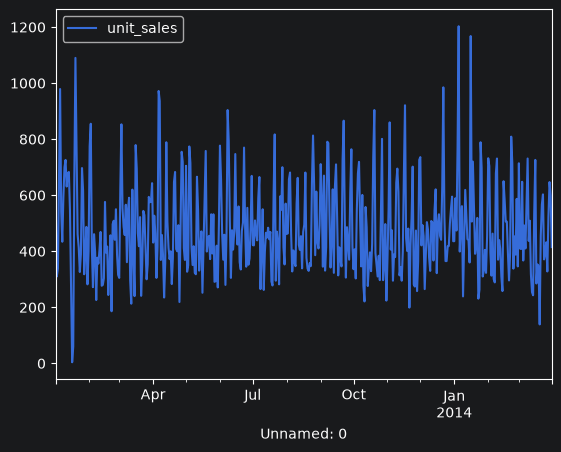

In [3]:
#visualize data
plt.figure(figsize=(21, 7))
data.plot()              ####label hinzufügen

In [4]:
# Split data (after 80% for training split)
#train, test = series.split_after(0.8)
#I want to split at a specific time:
train = data[data.index<'2014-01-01']
test = data[data.index>='2014-01-01']

#change to a timeseries object
train = TimeSeries.from_dataframe(train, value_cols='unit_sales')
test = TimeSeries.from_dataframe(test, value_cols='unit_sales')

## ARIMA

In [5]:
#ADF test to check for stationary. Null hypothesis: it is not stationary(for p>0,05)

# adfuller() doesn't work directly with timeseriesobjects. To extract the values:
train_val = train.values().flatten()   # Bei univariater Serie in 1D umwandeln
test_val = test.values().flatten()      #need this for later

# ADF-Test
result = adfuller(train_val) #sonst mit arr

if result[1] >= 0.05:
   print(f'Timeseries is not stationary: p= {result[1]}')
else:
    print(f'Timeseries is stationary: p= {result[1]}')


Timeseries is stationary: p= 0.0006123184685637161


In [6]:
'''
#we don't have to differentiate, but if we did, here's the code
# First Differentiation – new train-series with which we would do the steps that follow
diff1 = np.diff(arr, 1)
# ADF-Test with differentiated series
result = adfuller(diff1)
if result[1] >= 0.05:
   print(f'Timeseries is not stationary: p= {result[1]}')
else:
    print(f'Timeseries is stationary: p= {result[1]}')
# if its stationary : d=1
#if its still not stationary, repeat till it is, or better use other model
'''

"\n#we don't have to differentiate, but if we did, here's the code\n# First Differentiation – new train-series with which we would do the steps that follow\ndiff1 = np.diff(arr, 1)\n# ADF-Test with differentiated series\nresult = adfuller(diff1)\nif result[1] >= 0.05:\n   print(f'Timeseries is not stationary: p= {result[1]}')\nelse:\n    print(f'Timeseries is stationary: p= {result[1]}')\n# if its stationary : d=1\n#if its still not stationary, repeat till it is, or better use other model\n"

parameter for d=0. Data is stationary

#### parameter p für ARIMA
How many past days do I need to forecast? How many hold information?

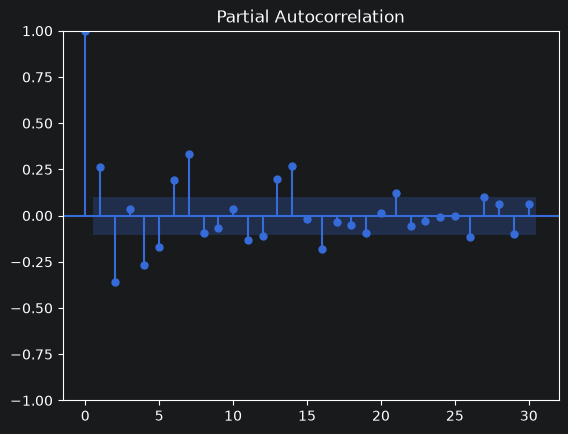

In [7]:
plot_pacf(train_val, lags=30) #lets look at the correlation 30 days in the past
plt.show()

0 is self correlation. 2 might fit (3 is under confidenzintervall (95%)), might try 7

=> p=2 / p=7

#### Parameter q: How many past mistakes should we learn from?

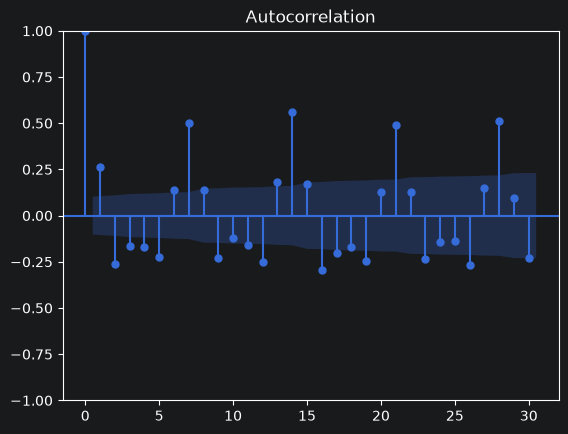

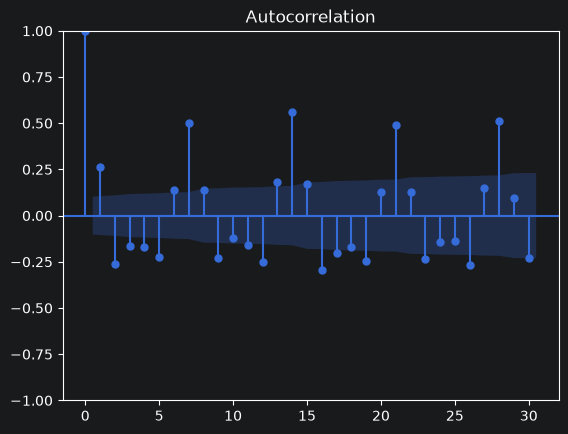

In [8]:
plot_acf(train_val, lags=30)

Looks very very seasonal. Repeating pattern with 7 Days -> weekly pattern. ARIMA is the wrong model, SARIMA would be a better fit. We'll still try ARIMA to compare and find the right hyperparameters. => Let's try q= 7

#### finding the best hyperparameters and training the model

In [9]:
from sklearn.model_selection import GridSearchCV

In [10]:
# trying with d=0, p= 2/7 and q=7
# gridsearch doesn't work for non sklearn models, so we do it manually
results_arima=[]        #to save the results

def best_params (p_list,d_list,q_list): # each one a list with possible parameters, that want to be tested
    warnings.filterwarnings("ignore") #a lot of parameters are not good. i don't want to see the warning for that
    for i in p_list:
        for j in d_list:
            for k in q_list:
                #train
                model_arima = ARIMA(p=i, d=j, q=k)
                model_arima.fit(train)
                forecast_arima=model_arima.predict(len(test))
                #evaluate
                aic=model_arima.model.aic
                mae = mean_absolute_error(test_val,forecast_arima.values().flatten())
                results_arima.append({'parameters': f'p={i},d={j}, q={k}','aic': aic, 'mae': mae})
    return results_arima

In [11]:
best_params([2,7],[0],[7])

[{'parameters': 'p=2,d=0, q=7',
  'aic': np.float64(4593.0506421823875),
  'mae': 114.4067444851239},
 {'parameters': 'p=7,d=0, q=7',
  'aic': np.float64(4519.93608762263),
  'mae': 105.73652324479691}]

In [12]:
#Warnings show not good parameters. Trying another grid, values near the expected ones
best_params([6,7,8],[0,1],[6,7,8])
results_arima= pd.DataFrame(results_arima)
print(results_arima.sort_values('aic').head())
print(results_arima.sort_values('mae').head())

      parameters          aic         mae
7   p=6,d=1, q=8  4503.300125  102.314145
12  p=7,d=1, q=7  4505.637717  104.884188
11  p=7,d=1, q=6  4505.983654  102.749763
13  p=7,d=1, q=8  4506.886616  104.749581
18  p=8,d=1, q=7  4507.160422  101.389378
      parameters          aic         mae
2   p=6,d=0, q=6  4527.373450   99.778332
17  p=8,d=1, q=6  4525.025698  100.047708
8   p=7,d=0, q=6  4513.051685  101.029528
18  p=8,d=1, q=7  4507.160422  101.389378
10  p=7,d=0, q=8  4517.855554  101.624267


although the adf test was stationary, the best results with aic were with d=1:
best aic is (6,1,8); best mae is (6,0,6). aic and mae are all not that different, so I choose nr 18 - it is the only one in both top five lists. so the best parameters are (8,1,7)

In [13]:
model_arima = ARIMA(p=8, d=1, q=7)
model_arima.fit(train)
forecast_arima=model_arima.predict(len(test))

In [14]:
#to compare the models later with the evaluation-metrics
model_evaluation=pd.DataFrame(columns=['model','aic','mae','mse','r2'])

aic=model_arima.model.aic
mae=mean_absolute_error(test_val,forecast_arima.values().flatten())
mse=mean_squared_error(test_val,forecast_arima.values().flatten())
r2= r2_score(test_val,forecast_arima.values().flatten())

#new entry for arima at the End of the DF (len()) with the metrics
model_evaluation.loc[len(model_evaluation)] = ['arima', aic, mae, mse, r2]

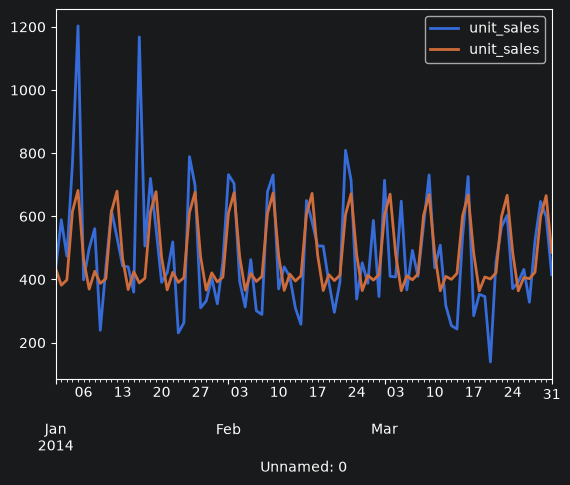

,model,aic,mae,mse,r2
0,arima,4507.160422,101.389378,21117.221404,0.372719


In [15]:
#let's see how it looks like
test.plot()
forecast_arima.plot()
plt.show()
model_evaluation

looks good for a model without seasonality. Let's see how the other models rank

## SARIMA

We already have the parameters p,d,q. Let's find P,D,Q and s/m

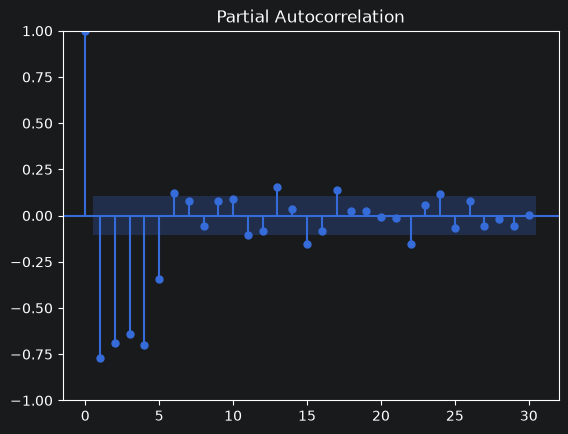

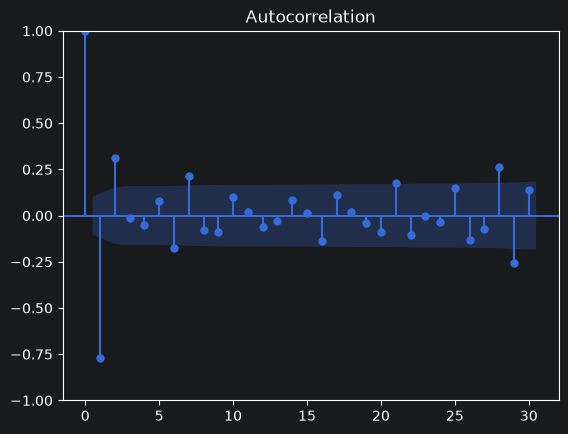

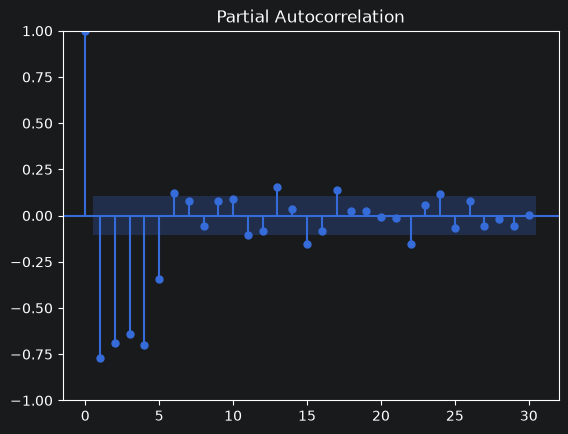

In [16]:
#in the plot before it looked like s is weekly, so 7
diff_s = np.diff(train_val, 7) #seasonal differentiation

plot_acf(diff_s, lags=30)   #for Q
plot_pacf(diff_s, lags=30)  #for P


seasonality seems to be gone => D=1 seems to be enough
PACF: till lag 6 significant -> P=1
ACF: lag 1*s significant -> Q=1

In [17]:
#I had p=8 & q=7 from ARIMA as starting points, but with a seasonality of s=7 that does not work. They have to be smaller then s, so I choose p=q=6 - it also had good values of mae. we can check it laterrr
model_sarima = ARIMA(p=6, d=1, q=6, seasonal_order=(1,1,1,7))
model_sarima.fit(train)
forecast_sarima=model_sarima.predict(len(test))
aic=model_sarima.model.aic
mae=mean_absolute_error(test_val,forecast_sarima.values().flatten())
print(aic, mae)

4455.224949258742 98.67992492334874


In [18]:
results_sarima=[] #again empty list

def best_params_sarima (p_list,d_list,q_list, P_list, D_list, Q_list): # again for sarima.. better don't try a lot of them, or it will take ages...
    #warnings.filterwarnings("ignore") #don't need that anymore, the model fits better
    for i in p_list:
        for j in d_list:
            for k in q_list:
                for l in P_list:
                    for m in D_list:
                        for n in Q_list:
                            #train
                            model_sarima = ARIMA(p=i, d=j, q=k, seasonal_order=(l,m,n,7))
                            model_sarima.fit(train)
                            forecast_sarima=model_sarima.predict(len(test))
                            #evaluate
                            aic=model_sarima.model.aic
                            mae = mean_absolute_error(test_val,forecast_sarima.values().flatten())
                            results_sarima.append({'parameters': f'p={i},d={j}, q={k}, P={l}, D={m},Q={n}','aic': aic, 'mae': mae})
    return results_arima

In [19]:
# First, I try with very little Input, and try to get near the best parameters
best_params_sarima([5,6],[0,1],[5,6],[1],[1],[1])
results_sarima= pd.DataFrame(results_sarima)
print(results_sarima.sort_values('aic').head())
print(results_sarima.sort_values('mae').head())

                   parameters          aic         mae
5  p=6,d=0, q=6, P=1, D=1,Q=1  4437.620676  100.162711
0  p=5,d=0, q=5, P=1, D=1,Q=1  4447.614165  100.742818
4  p=6,d=0, q=5, P=1, D=1,Q=1  4448.021928   96.970471
1  p=5,d=0, q=6, P=1, D=1,Q=1  4452.338672   98.107885
7  p=6,d=1, q=6, P=1, D=1,Q=1  4455.224949   98.679925
                   parameters          aic        mae
6  p=6,d=1, q=5, P=1, D=1,Q=1  4455.311132  96.793209
4  p=6,d=0, q=5, P=1, D=1,Q=1  4448.021928  96.970471
1  p=5,d=0, q=6, P=1, D=1,Q=1  4452.338672  98.107885
7  p=6,d=1, q=6, P=1, D=1,Q=1  4455.224949  98.679925
3  p=5,d=1, q=6, P=1, D=1,Q=1  4463.849831  99.301492


In [20]:
#I set 6,0,6 for pdq (is true with the adf test from the beginning
# lets try out some more
results_sarima=[] #empty the list
best_params_sarima([6],[0],[6],[0,1,2],[1],[0,1,2])
results_sarima= pd.DataFrame(results_sarima)
print(results_sarima.sort_values('aic').head())
print(results_sarima.sort_values('mae').head())

                   parameters          aic         mae
2  p=6,d=0, q=6, P=0, D=1,Q=2  4437.437001  100.825109
4  p=6,d=0, q=6, P=1, D=1,Q=1  4437.620676  100.162711
1  p=6,d=0, q=6, P=0, D=1,Q=1  4437.847688  100.135889
8  p=6,d=0, q=6, P=2, D=1,Q=2  4439.320460  102.905282
7  p=6,d=0, q=6, P=2, D=1,Q=1  4439.729744  100.979018
                   parameters          aic         mae
1  p=6,d=0, q=6, P=0, D=1,Q=1  4437.847688  100.135889
4  p=6,d=0, q=6, P=1, D=1,Q=1  4437.620676  100.162711
2  p=6,d=0, q=6, P=0, D=1,Q=2  4437.437001  100.825109
7  p=6,d=0, q=6, P=2, D=1,Q=1  4439.729744  100.979018
5  p=6,d=0, q=6, P=1, D=1,Q=2  4440.566149  102.092014


In [21]:
#P=D=Q=1 seems to be the best with aic and mae
# lets try out some more
results_sarima=[]
best_params_sarima([1,3,5],[0],[1,3,5],[1],[1],[1])
results_sarima= pd.DataFrame(results_sarima)
print(results_sarima.sort_values('aic').head())
print(results_sarima.sort_values('mae').head())

                   parameters          aic        mae
7  p=5,d=0, q=3, P=1, D=1,Q=1  4409.911981  96.364237
0  p=1,d=0, q=1, P=1, D=1,Q=1  4410.006161  94.293870
1  p=1,d=0, q=3, P=1, D=1,Q=1  4411.139574  94.201392
3  p=3,d=0, q=1, P=1, D=1,Q=1  4413.580786  95.461883
2  p=1,d=0, q=5, P=1, D=1,Q=1  4415.801340  94.410660
                   parameters          aic        mae
1  p=1,d=0, q=3, P=1, D=1,Q=1  4411.139574  94.201392
0  p=1,d=0, q=1, P=1, D=1,Q=1  4410.006161  94.293870
4  p=3,d=0, q=3, P=1, D=1,Q=1  4417.999508  94.294674
2  p=1,d=0, q=5, P=1, D=1,Q=1  4415.801340  94.410660
5  p=3,d=0, q=5, P=1, D=1,Q=1  4420.016745  95.216745


In [22]:
#p=1=q seems to be good, let's try some more nearer these numbers
results_sarima=[]
best_params_sarima([0,1,2],[0],[0,1,2],[1],[1],[1])
results_sarima= pd.DataFrame(results_sarima)
print(results_sarima.sort_values('aic').head())
print(results_sarima.sort_values('mae').head())

                   parameters          aic        mae
1  p=0,d=0, q=1, P=1, D=1,Q=1  4408.695540  94.498911
5  p=1,d=0, q=2, P=1, D=1,Q=1  4409.342112  94.161148
4  p=1,d=0, q=1, P=1, D=1,Q=1  4410.006161  94.293870
2  p=0,d=0, q=2, P=1, D=1,Q=1  4410.335102  94.415280
3  p=1,d=0, q=0, P=1, D=1,Q=1  4410.852912  94.600084
                   parameters          aic        mae
5  p=1,d=0, q=2, P=1, D=1,Q=1  4409.342112  94.161148
4  p=1,d=0, q=1, P=1, D=1,Q=1  4410.006161  94.293870
2  p=0,d=0, q=2, P=1, D=1,Q=1  4410.335102  94.415280
1  p=0,d=0, q=1, P=1, D=1,Q=1  4408.695540  94.498911
0  p=0,d=0, q=0, P=1, D=1,Q=1  4428.708156  94.514122


still really good, but I'll settle for #5:p=1,d=0,q=2. (Could try even more, e.g. s=30, but I have to make a cut somewhere)

In [23]:
#adding the numbers to the list above
model_sarima = ARIMA(p=1, d=0, q=2, seasonal_order=(1,1,1,7))
model_sarima.fit(train)
forecast_sarima=model_sarima.predict(len(test))

aic=model_sarima.model.aic
mae=mean_absolute_error(test_val,forecast_sarima.values().flatten())
mse=mean_squared_error(test_val,forecast_sarima.values().flatten())
r2= r2_score(test_val,forecast_sarima.values().flatten())

#new entry for arima at the End of the DF (len()) with the metrics
model_evaluation.loc[len(model_evaluation)] = ['sarima', aic, mae, mse, r2]

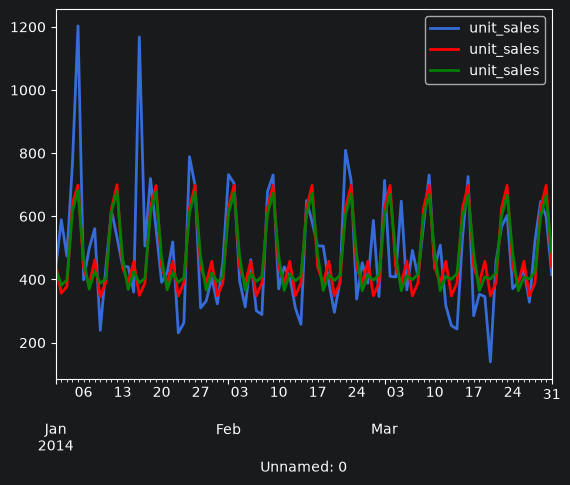

,model,aic,mae,mse,r2
0,arima,4507.160422,101.389378,21117.221404,0.372719
1,sarima,4409.342112,94.161148,20300.643550,0.396975


In [24]:
#let's look at both
test.plot()
forecast_sarima.plot(color='red')
forecast_arima.plot(color='green')
plt.show()
model_evaluation

## Prophet

In [25]:
#trying this model, as it also doesn't need any Features and no tuning
#Only thing: it expects two columns exactly named like this

train_prophet = train.to_dataframe()
train_prophet.reset_index(inplace=True)
train_prophet['ds']=train_prophet['Unnamed: 0']     #copying values &
train_prophet['y']=train_prophet['unit_sales']      #new column

#delete old column
train_prophet.drop(['Unnamed: 0','unit_sales'],axis=1, inplace=True)

In [26]:
#training model
model_prophet = Prophet()
model_prophet.fit(train_prophet)

forecast_prophet = model_prophet.make_future_dataframe(periods=len(test))  #as always three months
forecast_prophet = model_prophet.predict(forecast_prophet)

08:48:41 - cmdstanpy - INFO - Chain [1] start processing
08:48:42 - cmdstanpy - INFO - Chain [1] done processing


In [27]:
#visualize
#test.plot()
#model_prophet.plot(forecast_prophet)
#forecast_sarima.plot(color='red')
#forecast_arima.plot(color='green')
#plt.show()

In [28]:
#model_prophet.plot_components(forecast_prophet)

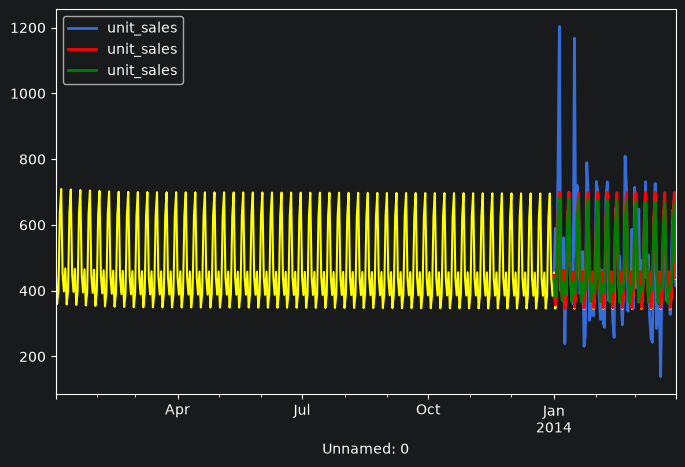

In [29]:
# both was not very informational. after inspection of the given Df
test.plot()

plt.plot(forecast_prophet['ds'],forecast_prophet['yhat'],color='yellow')

forecast_sarima.plot(color='red')
forecast_arima.plot(color='green')
plt.show()

 in the result is too much data. deleting it:

In [39]:
forecast_prophet_y=pd.DataFrame()   #new df

In [41]:
forecast_prophet_y['unit_sales']=forecast_prophet['yhat']       #copying the values
forecast_prophet_y['date']= forecast_prophet['ds']
forecast_prophet_y['date']=pd.to_datetime(forecast_prophet_y['date'])   #date to datetime object
forecast_prophet_y=forecast_prophet_y.iloc[-len(test): ]   #only the forecast
forecast_prophet_y.set_index('date', inplace=True)          #setting the index to the date

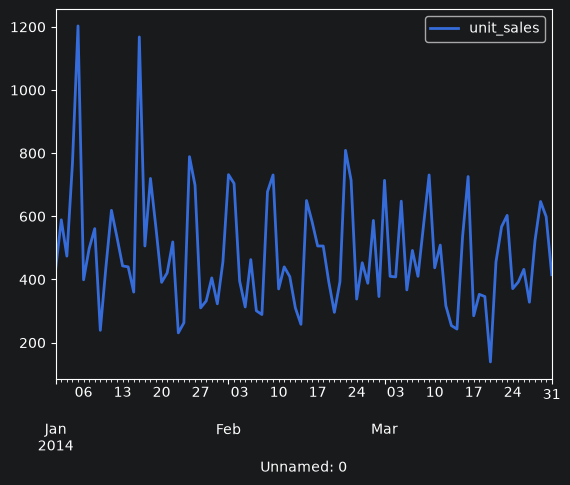

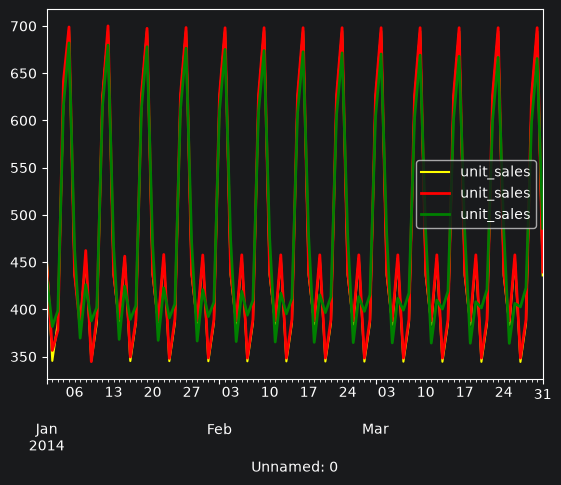

In [47]:
test.plot()
forecast_prophet_y.plot(color='yellow')
forecast_sarima.plot(color='red')
forecast_arima.plot(color='green')
plt.show()

seems to be very close to sarima

In [53]:
mae=mean_absolute_error(test_val,forecast_prophet_y['unit_sales'])
mse=mean_squared_error(test_val,forecast_prophet_y['unit_sales'])
r2= r2_score(test_val,forecast_prophet_y['unit_sales'])

#new entry for arima at the End of the DF (len()) with the metrics
#prophet is a additive regression model - doesn't have aic
model_evaluation.loc[len(model_evaluation)] = ['prophet','-', mae, mse, r2]

In [54]:
model_evaluation

,model,aic,mae,mse,r2
0,arima,4507.160422,101.389378,21117.221404,0.372719
1,sarima,4409.342112,94.161148,20300.643550,0.396975
2,prophet,-,94.329892,20448.171895,0.392592
3,prophet,-,94.329892,20448.171895,0.392592


prophet is similar to sarima in the evaluation, but with no parameters that have to be found and more work to make the data accessible.
sarima is better than arima, because it also implements the seasonality of the data.